# Exploratory Data Analysis

Loading and exploring the `MINDsmall_train` split (news metadata + user behavior logs).

## Setup
Import common libraries and verify that the dataset files are present.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

In [2]:
DATA_DIR = Path('smallDataset') / 'MINDsmall_train'
BEHAVIORS_PATH = DATA_DIR / 'behaviors.tsv'
NEWS_PATH = DATA_DIR / 'news.tsv'
ENTITY_EMBEDDING_PATH = DATA_DIR / 'entity_embedding.vec'
RELATION_EMBEDDING_PATH = DATA_DIR / 'relation_embedding.vec'

for dataset_path in [BEHAVIORS_PATH, NEWS_PATH, ENTITY_EMBEDDING_PATH, RELATION_EMBEDDING_PATH]:
    if not dataset_path.exists():
        raise FileNotFoundError(f'Missing dataset file: {dataset_path}')

print(f'Data directory: {DATA_DIR.resolve()}')
print(f'Behaviors size: {BEHAVIORS_PATH.stat().st_size / 1e6:.1f} MB')
print(f'News size: {NEWS_PATH.stat().st_size / 1e6:.1f} MB')
print(f'Entity embedding size: {ENTITY_EMBEDDING_PATH.stat().st_size / 1e6:.1f} MB')
print(f'Relation embedding size: {RELATION_EMBEDDING_PATH.stat().st_size / 1e6:.1f} MB')

Data directory: /home/asmvas/Documents/NTNU-prosjekt/anbefalingssytem/AnbSysProsjekt/smallDataset/MINDsmall_train
Behaviors size: 92.0 MB
News size: 41.2 MB
Entity embedding size: 25.8 MB
Relation embedding size: 1.0 MB


In [3]:
behavior_columns = ['impression_id', 'user_id', 'time', 'history', 'impressions']
news_columns = [
    'news_id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities'
]

behaviors_df = pd.read_csv(
    BEHAVIORS_PATH,
    sep='	',
    names=behavior_columns,
    parse_dates=['time'],
    keep_default_na=False,
    na_values=['', 'null', 'None']
)

news_df = pd.read_csv(
    NEWS_PATH,
    sep='	',
    names=news_columns,
    keep_default_na=False,
    na_values=['', 'null', 'None']
)

print(f'Behaviors shape: {behaviors_df.shape}')
print(f'News shape: {news_df.shape}')

Behaviors shape: (156965, 5)
News shape: (51282, 8)


## First look at the raw tables

In [4]:
display(behaviors_df.head())
display(news_df[['news_id', 'category', 'subcategory', 'title']].head())

,impression_id,user_id,time,history,impressions
0,1,U13740,2019-11-11 09:05:58,N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0
1,2,U91836,2019-11-12 18:11:30,N31739 N6072 N63045 N23979 N35656 N43353 N8129 N1569 N17686 N13008 N21623 N6233 N14340 N48031 N62285 N44383 N23061 N...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N22407-0 N14592-0 N17059-1 N33677-0 N7821-0 N6890-0
2,3,U73700,2019-11-14 07:01:48,N10732 N25792 N7563 N21087 N41087 N5445 N60384 N46616 N52500 N33164 N47289 N24233 N62058 N26378 N49475 N18870,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N59685-0 N23814-1 N23446-0 N64174-0 N11817-0 N60550-0 N48225-0 N45509-0...
3,4,U34670,2019-11-11 05:28:05,N45729 N2203 N871 N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,2019-11-12 16:11:21,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N60408-0 N61497-0 N47412-0 N41220-0 N1940-0 N724-0 N11363-0 N261-0 N3388...


,news_id,category,subcategory,title
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By"
1,N19639,health,weightloss,50 Worst Habits For Belly Fat
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches of Ukraine's War
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My Mental Health.
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a Dermatologist"


## High-level overview

In [5]:
time_min = behaviors_df['time'].min()
time_max = behaviors_df['time'].max()
time_range = f"{time_min.strftime('%Y-%m-%d %H:%M')} → {time_max.strftime('%Y-%m-%d %H:%M')}"

dataset_overview = pd.DataFrame(
    {
        'rows': [len(behaviors_df), len(news_df)],
        'unique_ids': [behaviors_df['user_id'].nunique(), news_df['news_id'].nunique()],
        'time_range': [time_range, 'N/A'],
        'notes': ['User impression logs', 'News metadata entries']
    },
    index=['behaviors', 'news']
)

display(dataset_overview)

,rows,unique_ids,time_range,notes
behaviors,156965,50000,2019-11-09 00:00 → 2019-11-14 23:59,User impression logs
news,51282,51282,N/A,News metadata entries


## Behavior-level signals

In [6]:
history_series = behaviors_df['history'].fillna('')
behaviors_df['history_len'] = history_series.apply(lambda x: 0 if x == '' else len(x.split()))

impressions_series = behaviors_df['impressions'].fillna('')
behaviors_df['impression_count'] = impressions_series.apply(lambda x: 0 if x == '' else len(x.split()))
behaviors_df['clicked_count'] = impressions_series.str.count('-1').astype('int32')
behaviors_df['not_clicked_count'] = (behaviors_df['impression_count'] - behaviors_df['clicked_count']).astype('int32')
behaviors_df['click_through_rate'] = np.where(
    behaviors_df['impression_count'] > 0,
    behaviors_df['clicked_count'] / behaviors_df['impression_count'],
    np.nan
)

total_impressions = behaviors_df['impression_count'].sum()
total_clicks = behaviors_df['clicked_count'].sum()
overall_ctr = total_clicks / total_impressions

print(f'Total impressions: {total_impressions:,}')
print(f'Total clicks: {total_clicks:,}')
print(f'Overall CTR: {overall_ctr:.3%}')

behavior_summary = behaviors_df[['history_len', 'impression_count', 'clicked_count', 'click_through_rate']].describe().T
behavior_summary['mean'] = behavior_summary['mean'].round(2)
behavior_summary['std'] = behavior_summary['std'].round(2)

display(behavior_summary)

Total impressions: 5,843,444
Total clicks: 236,344
Overall CTR: 4.045%


,count,mean,std,min,25%,50%,75%,max
history_len,156965.0,32.54,40.27,0.000000,8.000000,19.000000,42.000,558.00
impression_count,156965.0,37.23,38.59,2.000000,10.000000,24.000000,51.000,299.00
clicked_count,156965.0,1.51,1.15,1.000000,1.000000,1.000000,2.000,35.00
click_through_rate,156965.0,0.11,0.13,0.003367,0.028571,0.055556,0.125,0.75


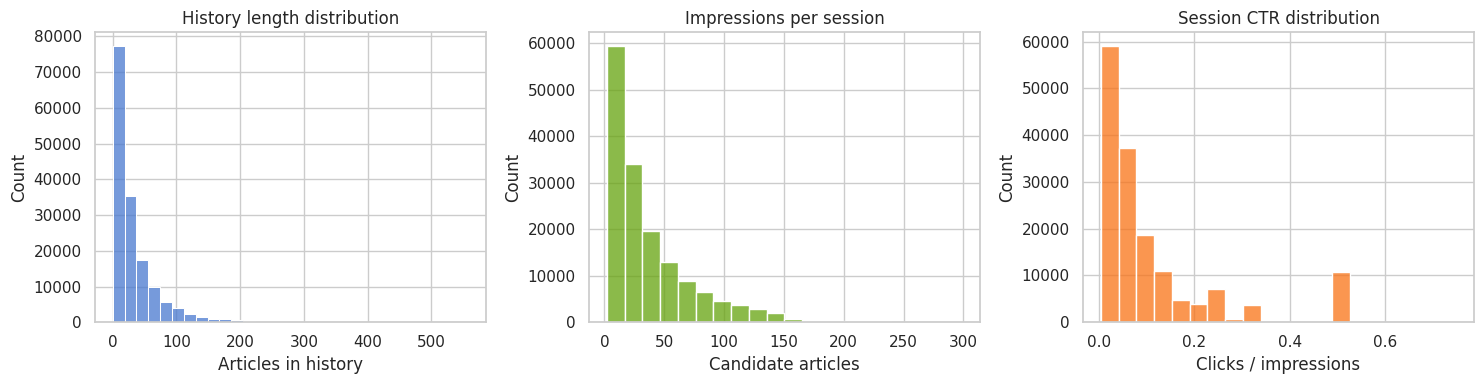

In [7]:
plot_sample = behaviors_df.sample(n=min(200000, len(behaviors_df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(plot_sample['history_len'], bins=30, ax=axes[0], color='#4878CF')
axes[0].set_title('History length distribution')
axes[0].set_xlabel('Articles in history')

sns.histplot(plot_sample['impression_count'], bins=20, ax=axes[1], color='#65A30D')
axes[1].set_title('Impressions per session')
axes[1].set_xlabel('Candidate articles')

sns.histplot(plot_sample['click_through_rate'].dropna(), bins=20, ax=axes[2], color='#F97316')
axes[2].set_title('Session CTR distribution')
axes[2].set_xlabel('Clicks / impressions')

plt.tight_layout()
plt.show()

## Impression-level breakdowns

Transform the candidate impression strings into a long-form table so we can analyze clicks at the news and temporal level.

In [8]:
def build_impression_table(df):
    subset = df[['impression_id', 'user_id', 'time', 'impressions']].copy()
    subset = subset[subset['impressions'].notna() & (subset['impressions'] != '')]
    subset['impressions_list'] = subset['impressions'].str.split()
    subset = subset.explode('impressions_list').dropna(subset=['impressions_list'])

    parts = subset['impressions_list'].str.rsplit('-', n=1, expand=True)
    subset['news_id'] = parts[0]
    subset['clicked'] = parts[1].astype('int8')
    subset['hour'] = subset['time'].dt.hour

    subset = subset.drop(columns=['impressions', 'impressions_list'])
    return subset

impressions_long = build_impression_table(behaviors_df).merge(
    news_df[['news_id', 'category', 'subcategory']],
    on='news_id',
    how='left'
)

print(f'Expanded impressions: {len(impressions_long):,}')
print(f"Click-through share: {impressions_long['clicked'].mean():.2%}")

Expanded impressions: 5,843,444
Click-through share: 4.04%


### Top clicked news categories

Mirror the reference analysis by surfacing which news categories accumulate the most confirmed clicks.

/tmp/ipykernel_13968/4237914077.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_clicked_categories.values, y=top_clicked_categories.index, palette='viridis', ax=ax)


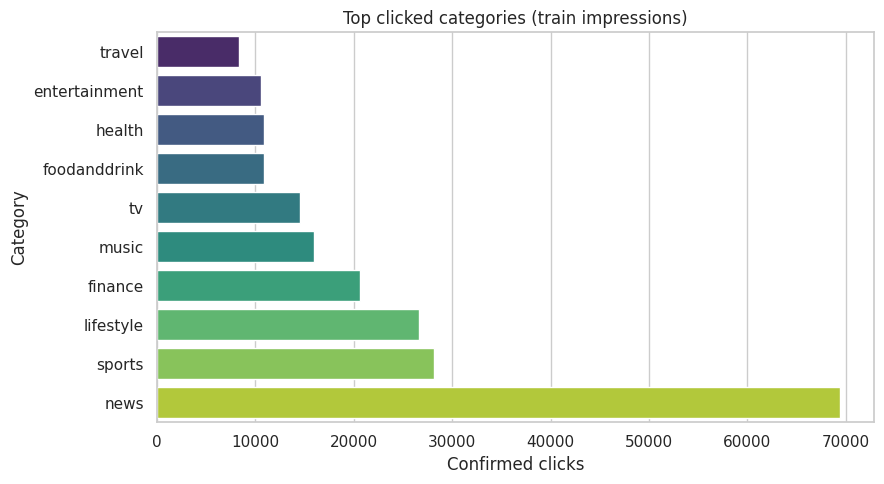

In [9]:
top_clicked_categories = (
    impressions_long.query('clicked == 1')['category']
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_clicked_categories.values, y=top_clicked_categories.index, palette='viridis', ax=ax)
ax.set_title('Top clicked categories (train impressions)')
ax.set_xlabel('Confirmed clicks')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

### Hourly click-through rate

Plot how the average click-through rate shifts throughout the day by aggregating every candidate impression into hourly buckets.

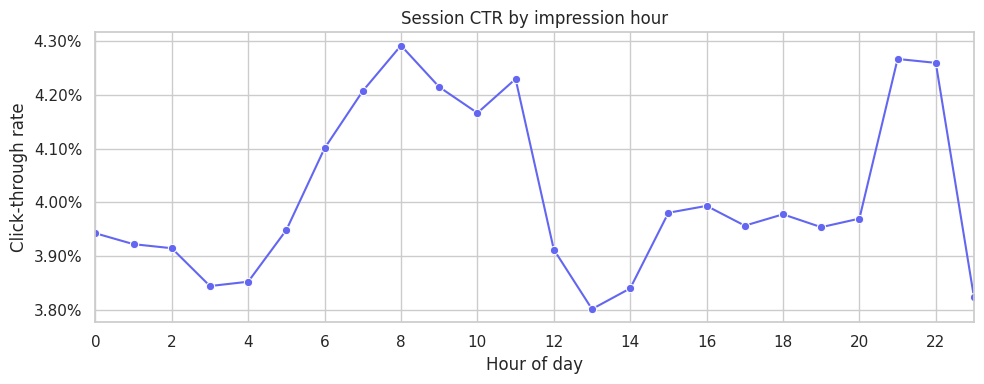

In [10]:
hourly_ctr = (
    impressions_long
    .groupby('hour')
    .agg(clicks=('clicked', 'sum'), impressions=('clicked', 'count'))
    .reset_index()
)

hourly_ctr['ctr'] = hourly_ctr['clicks'] / hourly_ctr['impressions']

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=hourly_ctr, x='hour', y='ctr', marker='o', ax=ax, color='#6366F1')
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Click-through rate')
ax.set_title('Session CTR by impression hour')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.tight_layout()
plt.show()

In [11]:
unique_users = test_b_df1['UserId'].unique()
sampled_users = pd.Series(unique_users).sample(frac=0.01, random_state=42)
sampled_test = test_b_df1[test_b_df1['UserId'].isin(sampled_users)]

# Transform the column to datetime
sampled_test['Time'] = pd.to_datetime(sampled_test['Time'])

# Assign each time a time of day
def assign_time_of_day(hour):
    if 6 <= hour <= 11:
        return 'morning'
    elif 12 <= hour <= 17:
        return 'afternoon'
    elif 18 <= hour <= 23:
        return 'evening'
    else:
        return 'night'

sampled_test['Time_of_Day'] = sampled_test['Time'].dt.hour.apply(lambda x: assign_time_of_day(x))

NameError: name 'test_b_df1' is not defined

## News-level signals

,count,mean,std,min,25%,50%,75%,max
title_length,51282.0,10.75,3.27,1.0,9.0,10.0,13.0,57.0
abstract_length,51282.0,34.29,26.54,0.0,15.0,24.0,62.0,474.0


,articles
category,
news,15774
sports,14510
finance,3107
foodanddrink,2551
lifestyle,2479
travel,2350
video,2068
weather,2048
health,1885


,articles
subcategory,
newsus,6564
football_nfl,5420
newspolitics,2826
newscrime,2254
weathertopstories,2047
newsworld,1720
football_ncaa,1665
baseball_mlb,1661
basketball_nba,1555


/tmp/ipykernel_13968/3972307615.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0], palette='crest')
/tmp/ipykernel_13968/3972307615.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_subcategories.values, y=top_subcategories.index, ax=axes[1], palette='mako')


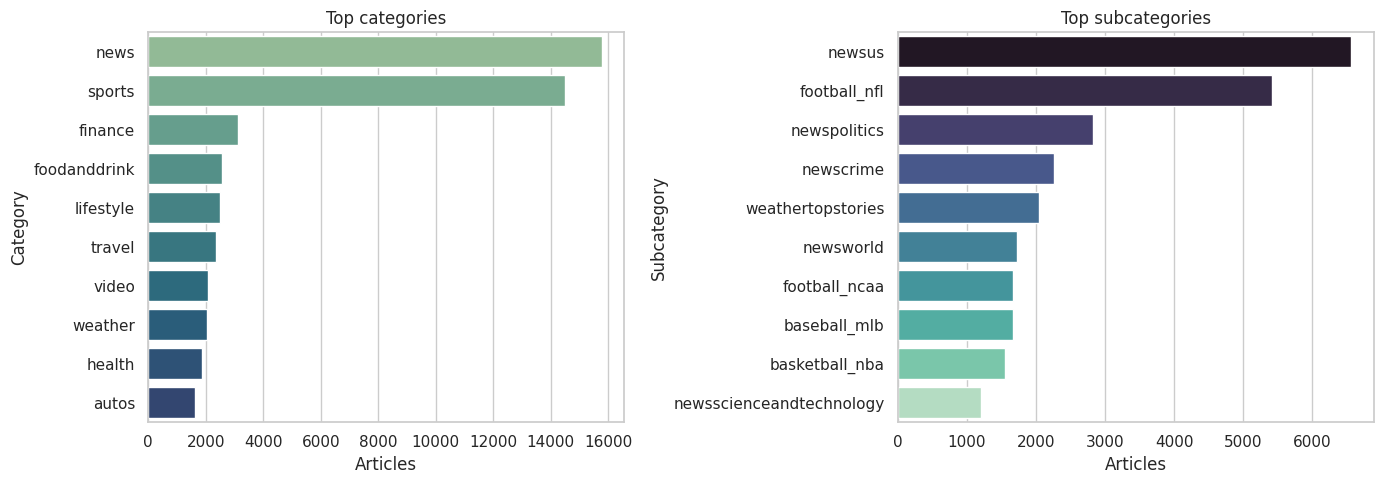

In [12]:
news_df['title_length'] = news_df['title'].fillna('').apply(lambda x: len(x.split()))
news_df['abstract_length'] = news_df['abstract'].fillna('').apply(lambda x: len(x.split()))

news_summary = news_df[['title_length', 'abstract_length']].describe().T.round(2)

top_categories = news_df['category'].value_counts().head(10)
top_subcategories = news_df['subcategory'].value_counts().head(10)

display(news_summary)
display(top_categories.to_frame('articles'))
display(top_subcategories.to_frame('articles'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0], palette='crest')
axes[0].set_title('Top categories')
axes[0].set_xlabel('Articles')
axes[0].set_ylabel('Category')

sns.barplot(x=top_subcategories.values, y=top_subcategories.index, ax=axes[1], palette='mako')
axes[1].set_title('Top subcategories')
axes[1].set_xlabel('Articles')
axes[1].set_ylabel('Subcategory')

plt.tight_layout()
plt.show()

### Text-length and survival-time insights

Wu et al. (ACL 2020) highlight several descriptive stats for MIND. The released small split only ships titles/abstracts, so the body plot below uses `title + abstract` as a proxy for the full article text while the survival time matches their definition (first to last impression).

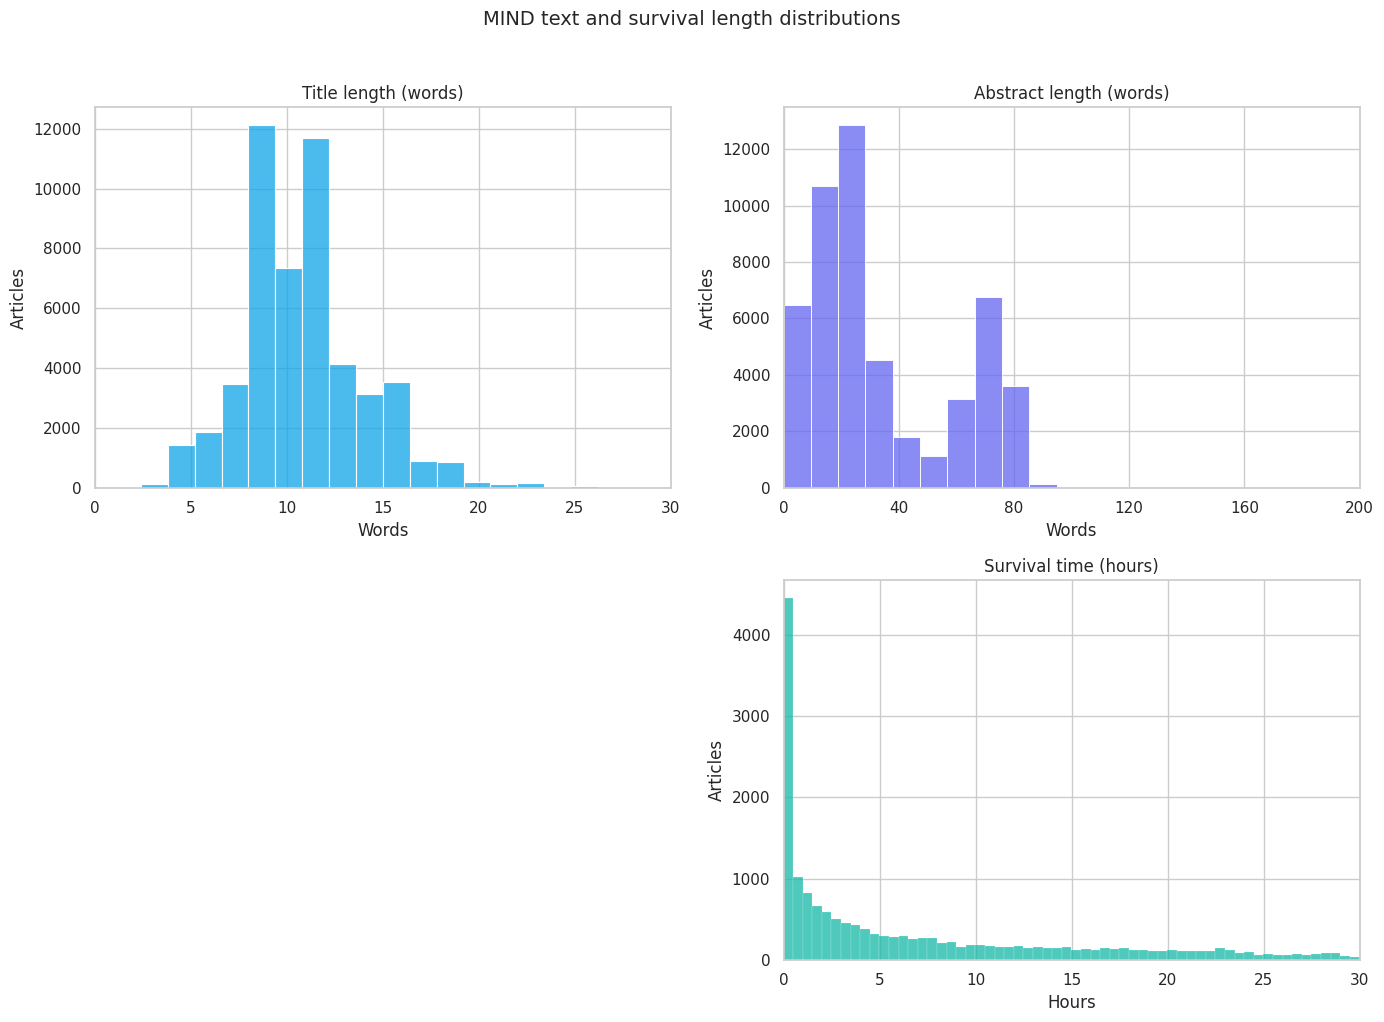

,hours
count,20288.000000
mean,17.609191
std,28.819419
min,0.000000
25%,0.788542
50%,5.830278
75%,20.407014
max,143.932500


In [24]:
survival_stats = (
    impressions_long
    .groupby('news_id')['time']
    .agg(first_seen='min', last_seen='max')
)
survival_stats['survival_hours'] = (
    (survival_stats['last_seen'] - survival_stats['first_seen']).dt.total_seconds() / 3600
).clip(lower=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.delaxes(axes[1, 0])  # remove unused bottom-left axis
plot_specs = [
    ('Title length (words)', news_df['title_length'].dropna(), axes[0, 0], {'bins': 40, 'color': '#0ea5e9'}),
    ('Abstract length (words)', news_df['abstract_length'].dropna(), axes[0, 1], {'bins': 50, 'color': '#6366f1'}),
    ('Survival time (hours)', survival_stats['survival_hours'].dropna(), axes[1, 1], {'binwidth': 0.5, 'color': '#14b8a6'})
]

for title, series, ax, kwargs in plot_specs:
    if title.startswith('Survival'):
        upper = min(168, series.max())
        kwargs.setdefault('binrange', (0, upper))
    sns.histplot(series, ax=ax, **kwargs)
    ax.set_title(title)
    ax.set_ylabel('Articles')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))

axes[0, 0].set_xlabel('Words')
axes[0, 1].set_xlabel('Words')
axes[1, 1].set_xlabel('Hours')

axes[0, 0].set_xlim(0, 30)
axes[0, 1].set_xlim(0, 200)
axes[1, 1].set_xlim(0, 30) # Kommenter ut for fullt spektrum

plt.suptitle('MIND text and survival length distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

display(survival_stats['survival_hours'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('hours'))


## Embedding overview

The train split ships with pretrained vectors for Wikidata entities and relations that power knowledge-aware recommenders. The cells below load them and highlight their basic properties.

In [14]:
def load_embedding_table(path, id_col):
    table = pd.read_csv(path, sep='	', header=None, dtype={0: 'string'}, low_memory=False)
    dim = table.shape[1] - 1
    vector_cols = [f'emb_{i:03d}' for i in range(1, dim + 1)]
    table.columns = [id_col] + vector_cols
    table[vector_cols] = table[vector_cols].astype('float32')
    return table, vector_cols

entity_embeddings, entity_vector_cols = load_embedding_table(ENTITY_EMBEDDING_PATH, 'entity_id')
relation_embeddings, relation_vector_cols = load_embedding_table(RELATION_EMBEDDING_PATH, 'relation_id')

print(f'Entity embeddings: {entity_embeddings.shape[0]:,} vectors with dimension {len(entity_vector_cols)}')
print(f'Relation embeddings: {relation_embeddings.shape[0]:,} vectors with dimension {len(relation_vector_cols)}')

Entity embeddings: 26,904 vectors with dimension 101
Relation embeddings: 1,091 vectors with dimension 101


### Summary statistics

In [15]:
def summarize_embeddings(table, vector_cols, label):
    vectors = table[vector_cols].to_numpy(dtype='float32')
    norms = np.linalg.norm(vectors, axis=1)
    summary = {
        'embedding': label,
        'vectors': len(table),
        'dimension': len(vector_cols),
    }
    return summary, norms

entity_summary, entity_norms = summarize_embeddings(entity_embeddings, entity_vector_cols, 'entity')
relation_summary, relation_norms = summarize_embeddings(relation_embeddings, relation_vector_cols, 'relation')

summary_df = pd.DataFrame([entity_summary, relation_summary])

display(summary_df)

display(entity_embeddings[['entity_id'] + entity_vector_cols[:5]].head())
display(relation_embeddings[['relation_id'] + relation_vector_cols[:5]].head())

,embedding,vectors,dimension
0,entity,26904,101
1,relation,1091,101


,entity_id,emb_001,emb_002,emb_003,emb_004,emb_005
0,Q41,-0.063388,-0.181451,0.057501,-0.091254,-0.076217
1,Q1860,0.060958,0.069934,0.015832,0.079471,-0.023362
2,Q39631,-0.093106,-0.052002,0.020556,-0.020801,0.043180
3,Q30,-0.115737,-0.179113,0.102739,-0.112469,-0.101853
4,Q60,-0.051036,-0.165637,0.132802,-0.089949,-0.146637


,relation_id,emb_001,emb_002,emb_003,emb_004,emb_005
0,P31,-0.073467,-0.132227,0.034173,-0.032769,0.008289
1,P21,-0.078436,0.108589,-0.049429,-0.131355,0.049300
2,P106,-0.052137,0.052444,-0.019886,-0.152309,0.014144
3,P735,-0.051398,0.056219,0.068029,-0.137717,-0.030050
4,P108,0.091231,0.022526,0.059349,-0.141853,0.035025
